# Basic usage

<div class="note"><span class="note-t">TL;DR</span>
<p>A fast quickstart: build a small stochastic circuit, simulate it, and train its parameters with <code>optax</code>. It also runs the energy-based PISING gate and checks that sampled parameter-shift gradients match exact ones.</p>
</div>

In this tutorial, we build a parametrised stochastic circuit and train it end to end, so the whole Torx workflow shows up in a single pass before you reach for the detailed guides. It is the quickstart companion to [`01_introduction_to_parametrised_stochastic_circuits.ipynb`](01_introduction_to_parametrised_stochastic_circuits.ipynb), the full tour that introduces each gate and data primitive at a slower pace. Here we stay concrete and keep moving.

By the end, you can:

- build a `DiscretePCircuit` from gates and inspect it with `draw_circuit`,
- train its parameters against a target distribution on the `StateVectorSimulator`,
- run the energy-based `PISING` gate and watch it relax toward equilibrium, and
- compare sampled parameter-shift gradients against exact ones with the `SampleSimulator`.

## Setup

We start by importing the gates and simulators, resolving the helper path, and applying the shared plotting style and `savefig` utility used throughout the notebook.

In [1]:
from pathlib import Path
import sys

import equinox as eqx
import jax
import jax.numpy as jnp
import optax
from tqdm import tqdm

from torx.psc import (
    DiscretePCircuit,
    draw_circuit,
    PCNOT,
    PISING,
    PNOT,
    PSWAP,
    SampleSimulator,
    StateVectorSimulator,
)

# Resolve examples/helpers whether run from the repo root or from examples/.
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "helpers"))

In [2]:
from _notebook_paths import figure_dir
from _notebook_style import apply_notebook_style, make_savefig
import _nb01b as P

apply_notebook_style()
FIGURE_DIR = figure_dir(ROOT)
savefig = make_savefig(FIGURE_DIR)
SEED = 0

## Build a circuit and simulate it

A circuit is a list of gates that fixes the structure. Here we chain three Boolean pbit gates: a `PNOT` on site 0, a `PSWAP` across sites 0 and 1, and a `PCNOT` controlled on site 1. The `StateVectorSimulator` evolves the full probability vector over the four two-pbit configurations, which is exact and cheap at this size.

In [3]:
circuit = DiscretePCircuit(
    [
        PNOT(0),
        PSWAP([0, 1]),
        PCNOT([1, 0]),
    ]
)
sim = StateVectorSimulator()

`draw_circuit` prints the wiring, so you can confirm the structure before training.

In [4]:
draw_circuit(circuit)

     ┌──────┐┌───────┐┌───────┐  
p_0: ┤ PNOT ├┤ PSWAP ├┤ PCNOT ├──
     └──────┘│       │└───┬───┘  
             │       │    │      
p_1: ────────┤       ├────■──────
             └───────┘           


The parameters live in a separate pytree, one entry per gate. We draw random starting values, put the initial distribution on |00), and set up an Adam optimizer from `optax`.

In [5]:
key = jax.random.key(SEED)
init_keys = jax.random.split(key, len(circuit))
thetas = [
    jax.random.uniform(k, t.shape, minval=-1.0, maxval=1.0)
    for k, t in zip(init_keys, circuit.init_params(key))
]

optimizer = optax.adam(learning_rate=1e-2)
opt_state = optimizer.init(thetas)

init_state = jnp.zeros(4, dtype=jnp.float32).at[0].set(1.0)

The loss rebuilds the compiled circuit from `thetas` inside the function, so gradients flow straight back to the parameters. We push the output distribution toward an even split between |00) and |11) with a squared error, then wrap one Adam update in a jitted step.

In [6]:
@eqx.filter_value_and_grad
def loss_fn(thetas):
    compiled = sim.build_circuit(circuit, thetas)
    state = sim.density(compiled, init_state)
    target = jnp.array([0.5, 0.0, 0.0, 0.5])
    return jnp.sum((target - state) ** 2)


@eqx.filter_jit
def do_step(thetas, opt_state):
    loss, grads = loss_fn(thetas)
    updates, opt_state = optimizer.update(grads, opt_state)
    thetas = eqx.apply_updates(thetas, updates)
    return thetas, opt_state, loss

Run a thousand steps.

In [7]:
miniters = 100
train_loop = tqdm(range(1000), miniters=miniters)
losses = []
for step in train_loop:
    thetas, opt_state, loss = do_step(thetas, opt_state)
    losses.append(loss)
    if step % miniters == 0:
        train_loop.set_description(f"Step {step + 1}, Loss {loss:.5f}")

The trained distribution sits close to the target, with most of its mass on |00) and |11).

In [8]:
sim.density(sim.build_circuit(circuit, thetas), init_state)

Array([0.47782725, 0.00964574, 0.04025029, 0.47227672], dtype=float32)

The loss falls smoothly on a log scale.

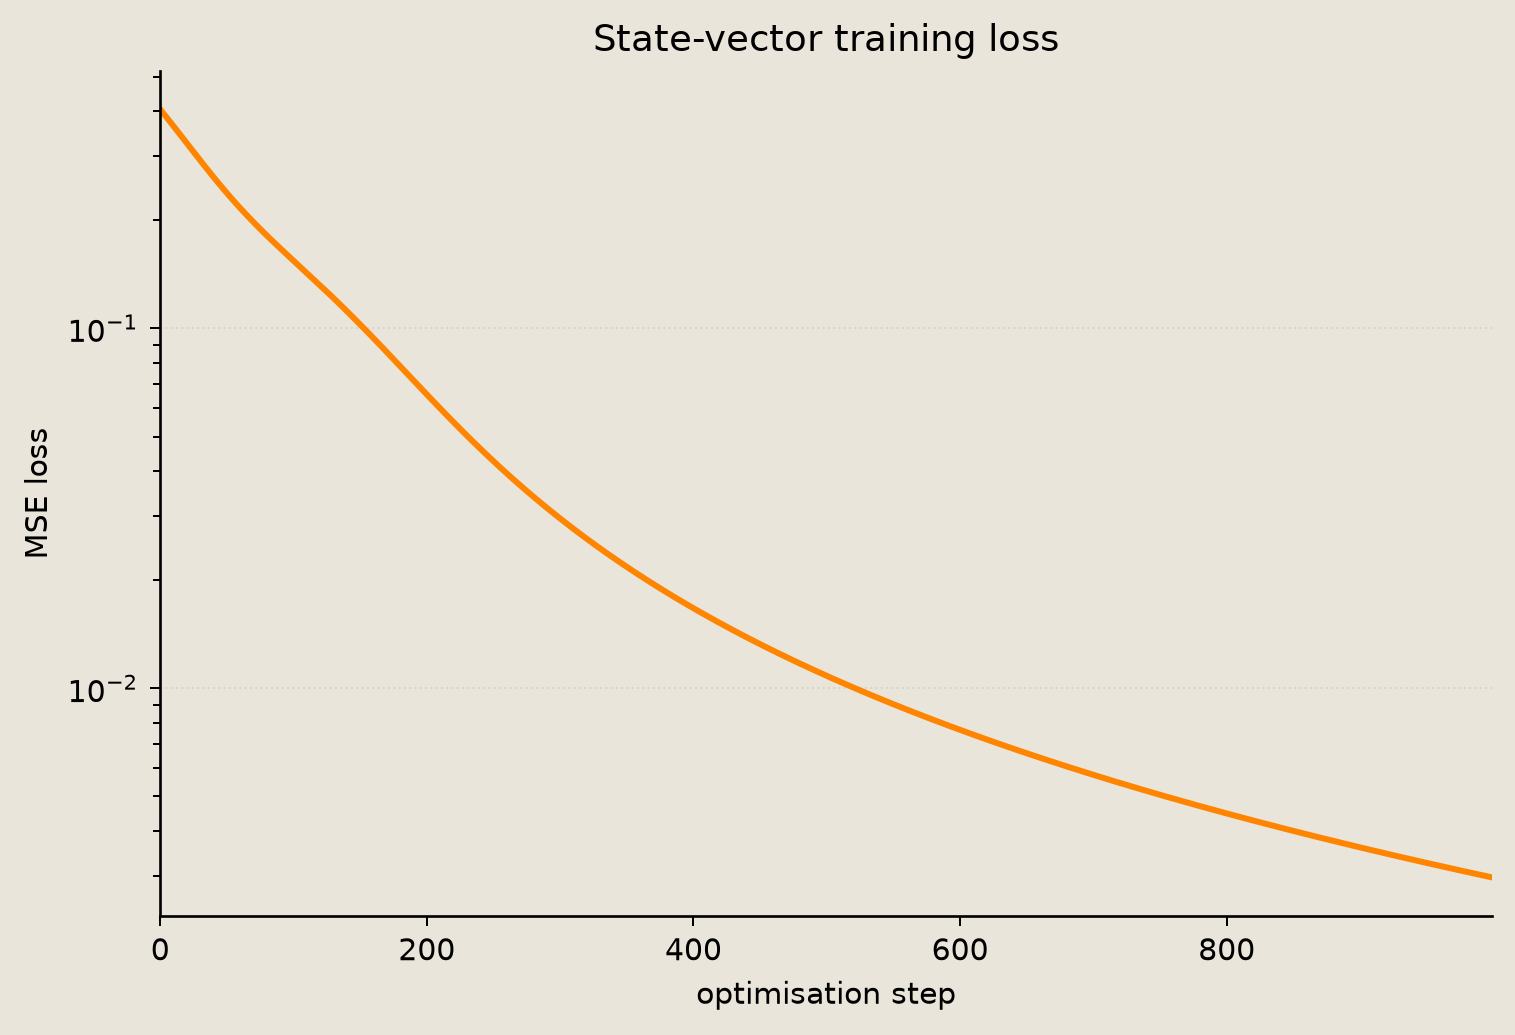

In [9]:
fig = P.training_loss(losses)
savefig(fig, "01b_training_loss")

## An energy-based gate: PISING

The Boolean gates above apply a fixed stochastic map. `PISING` is different: it thermalizes two pbits toward the Boltzmann distribution of a two-spin Ising model using Glauber dynamics. Its parameter is the five-vector `[J, h1, h2, beta, dt]`, supplied as the gate's `theta` at build time. `J` is the coupling, `h1` and `h2` are the local fields, `beta` is the inverse temperature, and `dt` sets how much relaxation is applied.

Starting from a uniform distribution, we sweep the step size `dt` at fixed ferromagnetic coupling. As `dt` grows, the two pbits align and the mass collects on the |00) and |11) states.

In [10]:
sim = StateVectorSimulator()
init_state = jnp.ones(4) / 4  # uniform over |00), |01), |10), |11)

coupling, beta = 1.0, 2.0
dts = [0.1, 1.0, 5.0]
labels = ["|00)", "|01)", "|10)", "|11)"]

dists = []
for dt in dts:
    gate_circuit = DiscretePCircuit([PISING([0, 1])])
    theta = jnp.array([coupling, 0.0, 0.0, beta, dt])  # [J, h1, h2, beta, dt]
    dists.append(sim.density(sim.build_circuit(gate_circuit, [theta]), init_state))

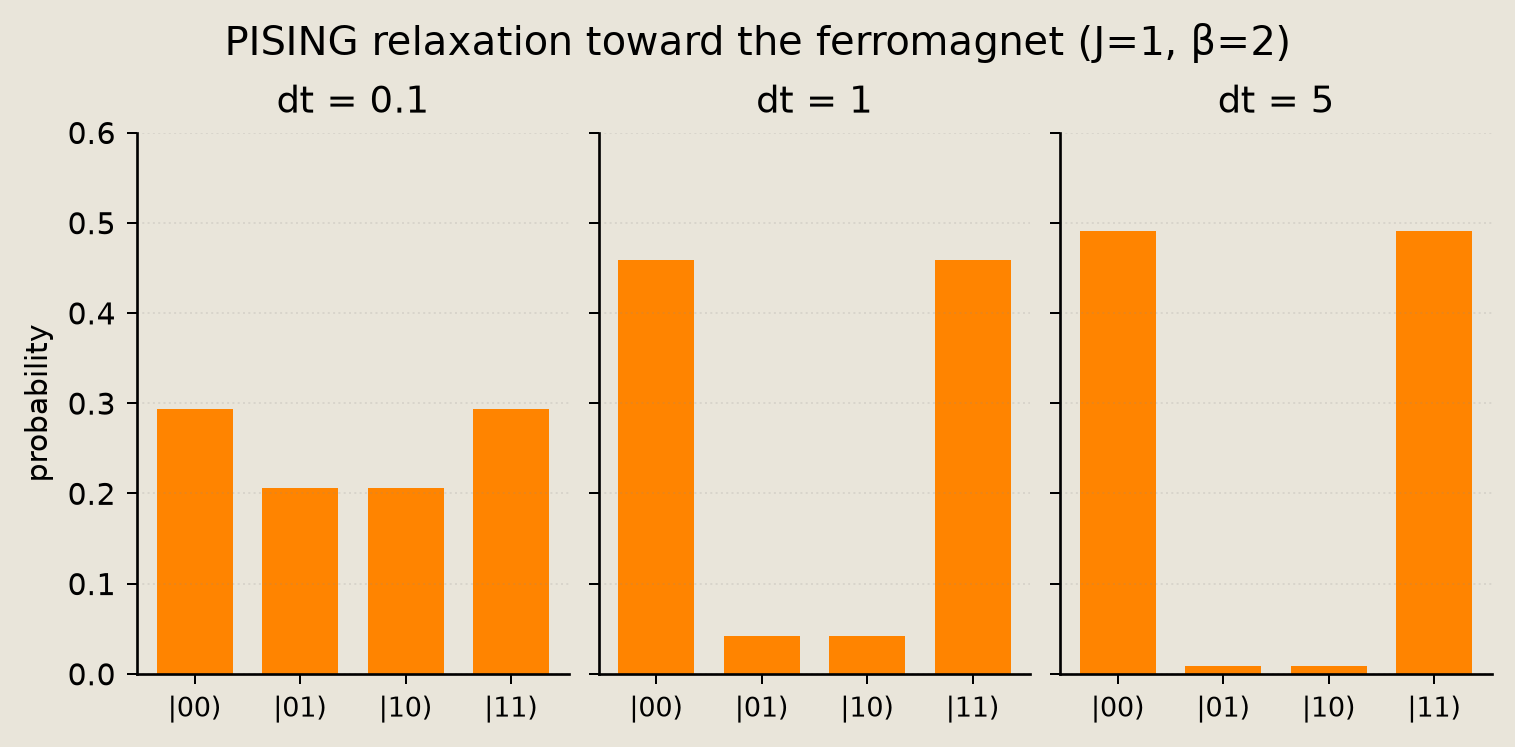

In [11]:
fig = P.pising_relaxation(dists, dts, labels=labels, coupling=coupling, beta=beta)
savefig(fig, "01b_pising_relaxation")

## Sampled vs exact gradients

The `SampleSimulator` estimates gradients by parameter-shift sampling, while the `StateVectorSimulator` computes them exactly. We train the same circuit from the same starting parameters down both paths and compare the loss curves. One run is driven by sampled gradients, the other by exact ones.

We compile each circuit once, outside the jitted step, and optimize the compiled circuit directly, since its parameters are inexact-array leaves. The sampled simulator bakes the structure into arrays during compilation, and that step cannot be re-run under `jit`, so it has to happen before the training loop.

Build the circuit and a shared set of random initial parameters.

In [12]:
circuit = DiscretePCircuit(
    [
        PNOT(0),
        PSWAP([0, 1]),
        PCNOT([1, 0]),
    ]
)

key = jax.random.key(SEED)
init_keys = jax.random.split(key, len(circuit))
base_thetas = [
    jax.random.uniform(k, t.shape, minval=-1.0, maxval=1.0)
    for k, t in zip(init_keys, circuit.init_params(key))
]

Compile the circuit once for each simulator, then give each path its own Adam optimizer and starting state.

In [13]:
sim = SampleSimulator(num_samples=1000, diff_method="param_shift_inf")
statevec_sim = StateVectorSimulator()

sampled_circuit = sim.build_circuit(circuit, base_thetas)
statevec_circuit = statevec_sim.build_circuit(circuit, base_thetas)

optimizer = optax.adam(learning_rate=1e-2)
opt_state = optimizer.init(eqx.filter(sampled_circuit, eqx.is_inexact_array))

optimizer_vec = optax.adam(learning_rate=1e-2)
opt_statevec = optimizer_vec.init(eqx.filter(statevec_circuit, eqx.is_inexact_array))

init_state = jnp.array([0, 0])
init_statevec = jnp.zeros(4, dtype=jnp.float32).at[0].set(1.0)

For each path, the loss is the negative expectation on the first pbit, and the step applies one Adam update. The sampled loss also takes a PRNG key for its Monte Carlo estimate.

In [14]:
@eqx.filter_value_and_grad
def loss_fn_exp(circuit, key):
    exp = sim.expval(circuit, init_state, 1, key)
    return -exp


@eqx.filter_jit
def do_step(circuit, opt_state, key):
    loss, grads = loss_fn_exp(circuit, key)
    updates, opt_state = optimizer.update(grads, opt_state)
    circuit = eqx.apply_updates(circuit, updates)
    return circuit, opt_state, loss

In [15]:
@eqx.filter_value_and_grad
def loss_fn_vec(circuit):
    """Negative expectation of pbit 1 under the exact statevector."""
    exp = statevec_sim.expval(circuit, init_statevec, 1)
    return -exp


@eqx.filter_jit
def do_step_vec(circuit, opt_state):
    """One optimizer step on the circuit parameters."""
    loss, grads = loss_fn_vec(circuit)
    updates, opt_state = optimizer_vec.update(grads, opt_state)
    circuit = eqx.apply_updates(circuit, updates)
    return circuit, opt_state, loss

Train both for two thousand steps.

In [16]:
miniters = 100
key = jax.random.key(SEED)
losses = []
losses_vec = []

train_loop = tqdm(range(2000), miniters=miniters)
for step in train_loop:
    key, subkey = jax.random.split(key)
    sampled_circuit, opt_state, loss = do_step(sampled_circuit, opt_state, subkey)
    losses.append(loss)
    if step % miniters == 0:
        train_loop.set_description(f"Step {step + 1}, Loss {loss:.5f}")

train_loop = tqdm(range(2000), miniters=miniters)
for step in train_loop:
    statevec_circuit, opt_statevec, loss_vec = do_step_vec(statevec_circuit, opt_statevec)
    losses_vec.append(loss_vec)
    if step % miniters == 0:
        train_loop.set_description(f"Step {step + 1}, Statevector Loss {loss_vec:.5f}")

  0%|          | 0/2000 [00:00<?, ?it/s]

Step 1, Loss -0.15400:   0%|          | 0/2000 [00:00<?, ?it/s]

Step 1, Loss -0.15400:   5%|▌         | 100/2000 [00:00<00:09, 210.22it/s]

Step 101, Loss -0.45100:   5%|▌         | 100/2000 [00:00<00:09, 210.22it/s]

Step 201, Loss -0.73000:   5%|▌         | 100/2000 [00:00<00:09, 210.22it/s]

...

Step 1601, Statevector Loss -0.99131:  70%|███████   | 1405/2000 [00:00<00:00, 4857.95it/s]

Step 1701, Statevector Loss -0.99223:  70%|███████   | 1405/2000 [00:00<00:00, 4857.95it/s]

Step 1801, Statevector Loss -0.99302:  70%|███████   | 1405/2000 [00:00<00:00, 4857.95it/s]

Step 1901, Statevector Loss -0.99370:  70%|███████   | 1405/2000 [00:00<00:00, 4857.95it/s]

Step 1901, Statevector Loss -0.99370: 100%|██████████| 2000/2000 [00:00<00:00, 4474.25it/s]

Both paths reach an expectation close to 1 on the target pbit.

In [17]:
print(init_state)
print(sim.expval(sampled_circuit, init_state, 1, key))
print(init_statevec)
print(statevec_sim.expval(statevec_circuit, init_statevec, 1))

[0 0]


0.99500006
[1. 0. 0. 0.]
0.994287


The sampled loss stays noisy but follows the exact curve down to the same optimum.

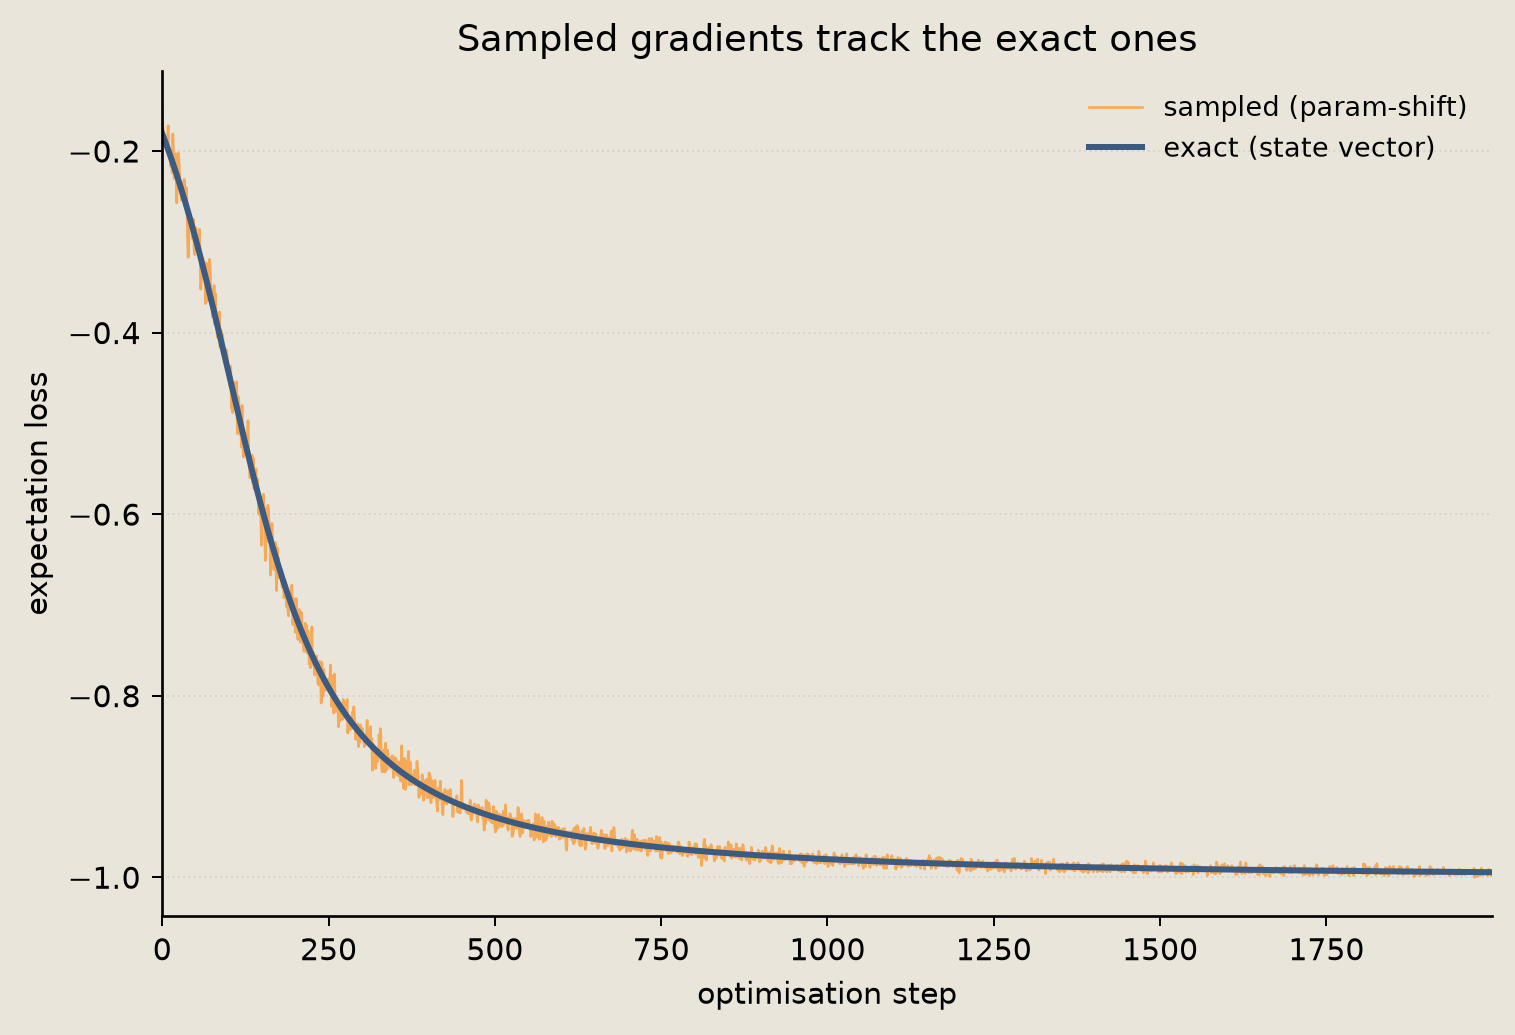

In [18]:
fig = P.gradient_comparison(losses, losses_vec)
savefig(fig, "01b_gradient_comparison")

## Where to go next

- [`01_introduction_to_parametrised_stochastic_circuits.ipynb`](01_introduction_to_parametrised_stochastic_circuits.ipynb) for the full tour of gates over pbits, pdits, and pmodes.
- [`04_execution_interface_readouts.ipynb`](04_execution_interface_readouts.ipynb) for the expectation readout used in the gradient comparison.
- [`06_ising_sampling_contrastive_divergence.ipynb`](06_ising_sampling_contrastive_divergence.ipynb) for `PISING` as a Gibbs sampler.